---
## **Project** : **Low-Rank Approximation and Matrix Completion**

---
## Hypothesis

The customer × product category purchase matrix has low-rank structure. This means that the behaviour of many customers can be approximately explained by a smaller number of latent consumption patterns.

If this is true, a rank-$k$ approximation

$$
A_k = U_k \Sigma_k V_k^\top
$$

with $k \ll \min(\text{customers}, \text{categories})$ should approximate the original matrix well in the Frobenius norm.

By the Eckart--Young theorem, the truncated SVD gives the best rank-$k$ approximation:

$$
\min_{\operatorname{rank}(B) \leq k} \|A - B\|_F
=
\|A - A_k\|_F
=
\sqrt{\sum_{i=k+1}^{r} \sigma_i^2}.
$$

In this project, the matrix $A$ has customers as rows and product categories as columns. Each entry is the total spend of a customer in a product category during the observation period. The matrix is large and sparse.

---

## Data and Matrix Construction

- **Source:** retail customer transaction history
- **Customers:** loyalty card holders
- **Products:** aggregated to level-5 product categories
- **Matrix entry:** total spend per customer-category pair
- **Matrix type:** sparse customer × category matrix
- **Preprocessing:** rows are normalized using the $\ell_2$ norm for the main SVD analysis

### Resulting Matrix

| Dimension | Value |
|---|---:|
| Customers | 300,395 |
| Categories | 498 |
| Non-zero entries | 20,513,291 |
| Density | 13.71% |

---

## Experimental Steps

| # | Step | Description |
|---|------|-------------|
| 1 | **Build the Matrix** | Aggregate transactions into a sparse customer × category matrix $A$ and record its shape, number of non-zero entries, and density. |
| 2 | **SVD and Singular Value Analysis** | Compute the top singular values using randomized SVD and plot their decay and cumulative energy. |
| 3 | **Low-Rank Approximation Error** | Compute the relative Frobenius error for different ranks $k$. |
| 4 | **Latent Pattern Interpretation** | Inspect the leading right singular vectors and list the most important product categories for each latent pattern. |
| 5 | **Customer Space Visualization** | Project customers into the first two latent dimensions to visualize structure in customer behaviour. |
| 6 | **Customer Clustering** | Apply K-Means to the customer latent features and describe the main categories in each cluster. |
| 7 | **SVD Method Comparison** | Compare randomized SVD with sparse SVD in terms of computation time and singular value accuracy. |
| 8 | **Customer Portrait** | Interpret one example customer using their top purchased categories and latent pattern coordinates. |
| 9 | **Matrix Completion Validation** | Hide 10% of observed entries, train SVD on the remaining entries, and predict the hidden values using RMSE and MAE. |
| 10 | **Baseline Comparison** | Compare SVD matrix completion with a simple category-average baseline. |

---


---
## 0. Setup : Import necessary libraries


In [ ]:
#!pip install pandas numpy scipy scikit-learn matplotlib pyarrow

import os
import glob
import zipfile
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.utils.extmath import randomized_svd
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
#-------------------------------------------------------------
# Mount Google Drive
# -----------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#--------------------------------------------------------
# Unzip datates
#----------------------------------------------------
zip_path = "/content/drive/MyDrive/Datasets.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
#------------------------------------
# Load the perquet files
#------------------------------------
# Get a list of all parquet files in the directory
parquet_files = glob.glob("/content/data/*.parquet")

# Read each parquet file into a DataFrame and concatenate them
dfs = [pd.read_parquet(file) for file in parquet_files]
df = pd.concat(dfs, ignore_index=True)

df.head()

,loy_card_cd,level_5,name_level_5,total_amt
0,9909966813734,149000018,Ананас,29990.00
1,9909973894887,122000009,Капустные,26535.70
2,1212507090685,139040203,Чай Черный,24990.00
3,9909940278160,149000008,Груши,19048.06
4,9909973098186,153020002,Жевательная Резинка,5490.00


---
## Step 1 — Build the Matrix

In [ ]:
# ============================================================
#  Build the customer-category sparse matrix
# ============================================================

# In this project, rows are customers and columns are product categories.
# Each value in the matrix is the total amount spent by one customer
# in one product category.

# First we aggregate the raw transactions by customer and product category.
agg = (
    df.groupby(['loy_card_cd', 'level_5'])['total_amt']
    .sum()
    .reset_index()
    .rename(columns={'total_amt': 'total_amount'})
)

# Make sure the spending amount is numeric.
# Any invalid values are converted to NaN and removed.
agg['total_amount'] = pd.to_numeric(agg['total_amount'], errors='coerce')
agg = agg.dropna(subset=['total_amount'])

# convert customer IDs and product categories into integer indices.
# This is necessary because sparse matrices need row/column numbers.
customer_codes = agg['loy_card_cd'].astype('category')
category_codes = agg['level_5'].astype('category')

agg['customer_idx'] = customer_codes.cat.codes.astype(np.int64)
agg['category_idx'] = category_codes.cat.codes.astype(np.int64)

# save mappings so that later we can translate matrix indices
# back to real customer IDs and category names.
idx_to_customer = dict(enumerate(customer_codes.cat.categories))
idx_to_category = dict(enumerate(category_codes.cat.categories))

n_customers = len(idx_to_customer)
n_categories = len(idx_to_category)

# build sparse matrix A.
# A[i, j] = total spending of customer i in category j.
A = csr_matrix(
    (
        agg['total_amount'].astype(np.float64).values,
        (
            agg['customer_idx'].values.astype(np.int64),
            agg['category_idx'].values.astype(np.int64)
        )
    ),
    shape=(n_customers, n_categories)
)

# Density shows how many entries are non-zero.
# A low density means most customer-category pairs have no recorded spending.
density = A.nnz / (float(n_customers) * float(n_categories))

print(f"Matrix shape : {A.shape}")
print(f"Non-zeros    : {A.nnz:,}")
print(f"Density      : {density:.4%}")

Matrix shape : (300395, 498)
Non-zeros    : 19,688,644
Density      : 13.1611%


---
## Step 2 — Spectral Analysis

In this section, we use randomized SVD because the matrix is large and sparse. Row normalization is applied so that customers are compared based on their relative buying behaviour rather than only their total spending level. The singular value plot helps to check whether the matrix has low-rank structure.

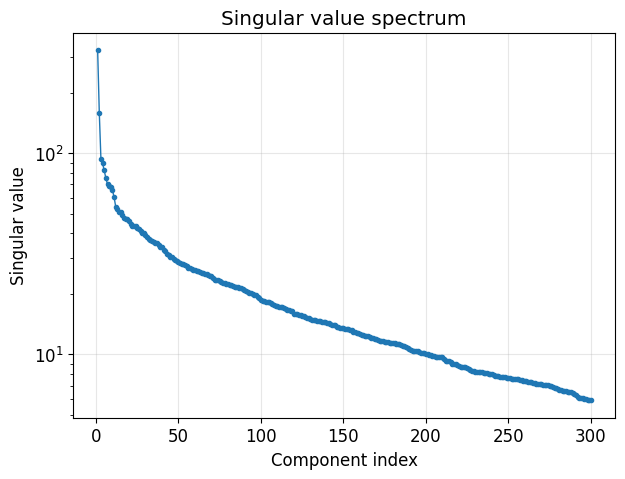

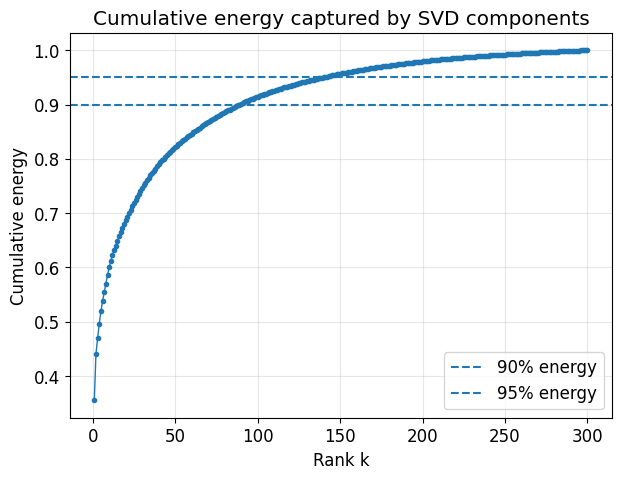

Number of components computed: 300
Rank for 90% computed energy: 89
Rank for 95% computed energy: 140


In [ ]:
# ============================================================
# Randomized SVD and spectral analysis
# ============================================================

# I normalize each customer row to length 1.
# This means the analysis focuses more on the customer's buying pattern
# across categories, not only on how much money the customer spent in total.
A_normalized = normalize(A, norm='l2', axis=1)

# Choose the number of singular values/components to compute.
# We cannot compute more components than the number of product categories.
K = min(300, A_normalized.shape[1] - 1)

# Apply randomized SVD.
# This gives an approximate low-rank decomposition:
# A_normalized ≈ U @ diag(sigma) @ Vt
U, sigma, Vt = randomized_svd(
    A_normalized,
    n_components=K,
    random_state=RANDOM_STATE
)

# Cumulative energy based on the computed singular values.
# This shows how much of the structure is captured by the first k components.
computed_energy = np.cumsum(sigma**2) / np.sum(sigma**2)

# Rank needed to explain 90% and 95% of the computed energy.
k_90 = np.argmax(computed_energy >= 0.90) + 1
k_95 = np.argmax(computed_energy >= 0.95) + 1

# Plot singular values.
# A fast decrease suggests that the matrix has low-rank structure.
plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, K + 1), sigma, 'o-', markersize=3, linewidth=1)
plt.xlabel('Component index')
plt.ylabel('Singular value')
plt.title('Singular value spectrum')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.savefig("singular_value_spectrum.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot cumulative energy.
# This helps us choose a reasonable rank k for approximation.
plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, K + 1), computed_energy, 'o-', markersize=3, linewidth=1)
plt.axhline(0.90, linestyle='--', label='90% energy')
plt.axhline(0.95, linestyle='--', label='95% energy')
plt.xlabel('Rank k')
plt.ylabel('Cumulative energy')
plt.title('Cumulative energy captured by SVD components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("cumulative_energy.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Number of components computed: {K}")
print(f"Rank for 90% computed energy: {k_90}")
print(f"Rank for 95% computed energy: {k_95}")

---
## Step 3 — Approximation Error Curve

This section measures how much information is lost when the original matrix is replaced by a rank-k approximation. The error is computed using the Frobenius norm. we use the exact norm of the sparse matrix so that the error curve is not artificially forced to become zero at the maximum computed rank.

k =    1  ||A - A_k||_F / ||A||_F = 0.8045
k =    5  ||A - A_k||_F / ||A||_F = 0.6965
k =   10  ||A - A_k||_F / ||A||_F = 0.6361
k =   20  ||A - A_k||_F / ||A||_F = 0.5643
k =   50  ||A - A_k||_F / ||A||_F = 0.4300
k =  100  ||A - A_k||_F / ||A||_F = 0.3041
k =  150  ||A - A_k||_F / ||A||_F = 0.2255
k =  200  ||A - A_k||_F / ||A||_F = 0.1678
k =  300  ||A - A_k||_F / ||A||_F = 0.0882


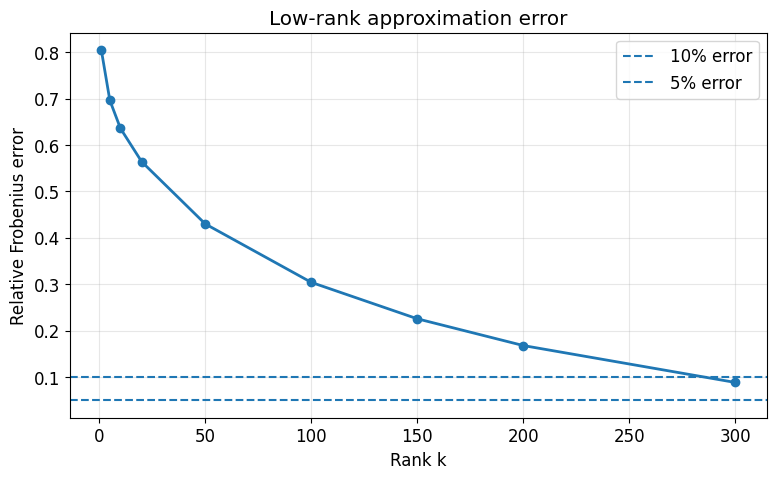

In [ ]:
#---------------------------------------------------------
# Low-rank approximation error
#----------------------------------------------------------

# check how the approximation error changes when I keep
# only the first k singular values.
# The relative Frobenius error is:
# ||A - A_k||_F / ||A||_F
# A smaller value means the rank-k approximation is closer to the original matrix.

ks = [1, 5, 10, 20, 50, 100, 150, 200, 300]
ks = [k for k in ks if k <= len(sigma)]

# Use the true Frobenius norm of the normalized sparse matrix.
# This is better than using only np.sum(sigma**2), because sigma only contains
# the singular values we computed.
total_energy_exact = A_normalized.power(2).sum()

errors = []

for k in ks:
    explained_energy = np.sum(sigma[:k]**2)
    remaining_energy = max(total_energy_exact - explained_energy, 0)
    rel_err = np.sqrt(remaining_energy / total_energy_exact)

    errors.append(rel_err)
    print(f"k = {k:4d}  ||A - A_k||_F / ||A||_F = {rel_err:.4f}")

# Ploting the error curve.
# if the error drops quickly, this supports the low-rank approximation theme.
plt.figure(figsize=(9, 5))
plt.plot(ks, errors, 'o-', linewidth=2)
plt.axhline(0.10, linestyle='--', label='10% error')
plt.axhline(0.05, linestyle='--', label='5% error')
plt.xlabel('Rank k')
plt.ylabel('Relative Frobenius error')
plt.title('Low-rank approximation error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("low_rank_error.png", dpi=300, bbox_inches="tight")

plt.show()

---
## Step 4 — Pattern Interpretation

This section helps interpret the low-rank model. Each latent pattern is a right singular vector from SVD and shows a combination of product categories that tend to appear together in customer spending behaviour. The categories with the largest absolute weights are the most important for understanding each pattern.

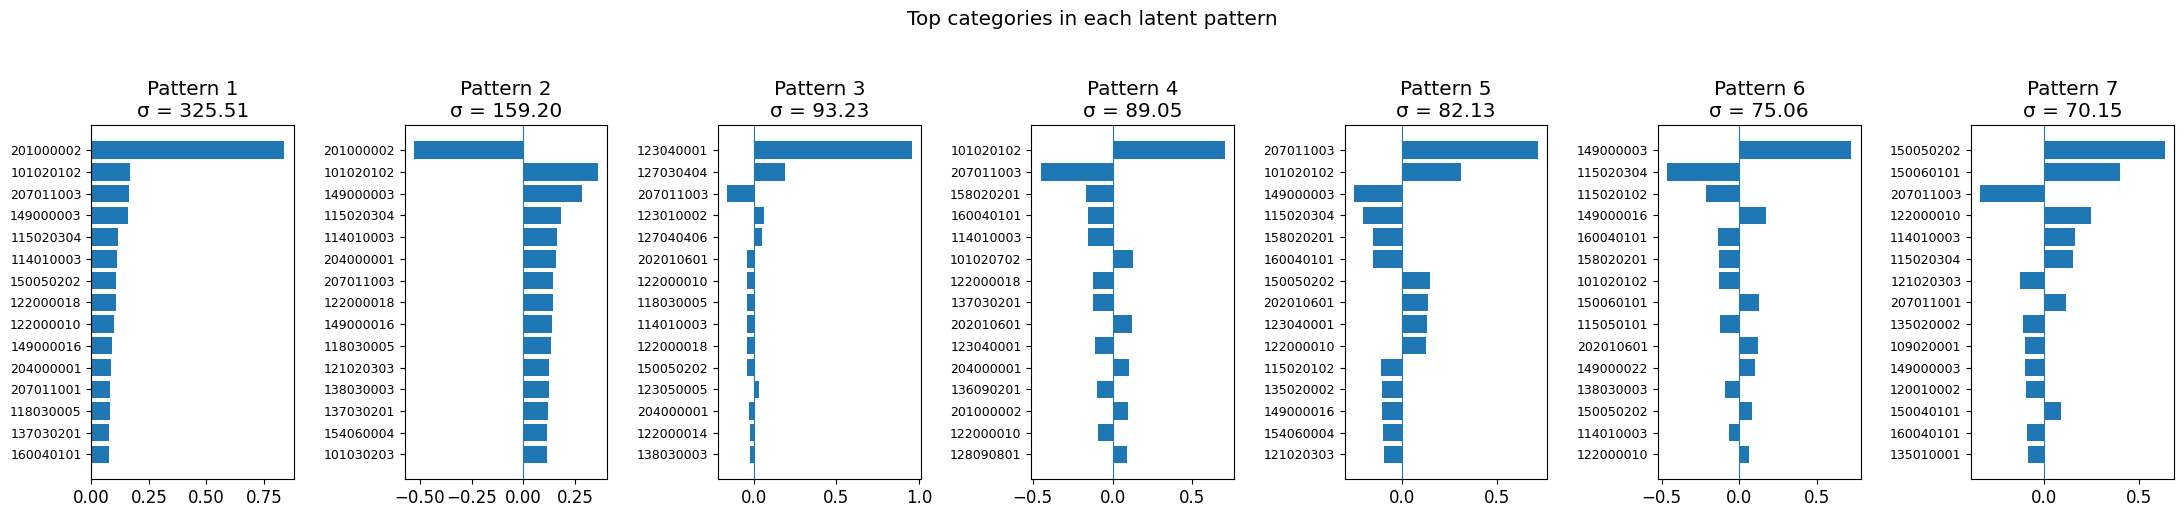

In [ ]:
# ============================================================
# Interpret latent patterns from the right singular vectors
# ============================================================
# Each row of Vt represents one latent pattern across product categories.
# Large positive or negative values show which categories contribute most
# to that pattern.

N_PATTERNS = min(7, Vt.shape[0])   # number of latent patterns to show
TOP_N = 15                         # number of top categories per pattern

fig, axes = plt.subplots(1, N_PATTERNS, figsize=(22, 5))

# If only one pattern is shown, make axes iterable
if N_PATTERNS == 1:
    axes = [axes]

for i in range(N_PATTERNS):
    vec = Vt[i]

    # Find the categories with the largest absolute weights in pattern i
    top_idx = np.argsort(np.abs(vec))[-TOP_N:][::-1]
    top_weights = vec[top_idx]

    # Convert matrix column indices back to real category names
    top_labels = [str(idx_to_category.get(j, j)) for j in top_idx]

    # Plot horizontal bar chart
    axes[i].barh(top_labels[::-1], top_weights[::-1])
    axes[i].set_title(f'Pattern {i+1}\nσ = {sigma[i]:.2f}')
    axes[i].axvline(0, linewidth=0.8)
    axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle('Top categories in each latent pattern', y=1.03)
plt.tight_layout()
plt.savefig("latent_patterns.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Step 5 — Customer Space Visualization

This plot shows customers projected into the first two latent dimensions from the SVD. Customers that appear close together in this space have more similar spending patterns across product categories.

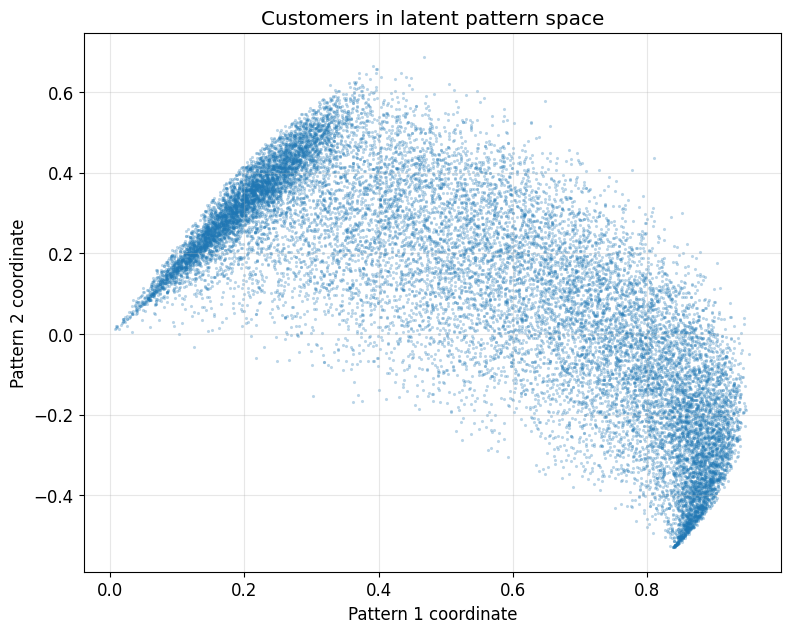

In [ ]:
# ============================================================
# Customer space visualization
# ============================================================
# Here I project customers onto the first two latent dimensions.
# U contains the customer singular vectors, and multiplying by sigma
# gives the customer coordinates in the latent space.

coords = U[:, :2] * sigma[:2]

# since the number of customers is very large, I only plot a sample
# so that the figure is easier to display and read.
N_SAMPLE = min(20_000, coords.shape[0])
idx_sample = np.random.choice(coords.shape[0], N_SAMPLE, replace=False)

# Scatter plot of customers in the first two latent dimensions
plt.figure(figsize=(9, 7))
plt.scatter(
    coords[idx_sample, 0],
    coords[idx_sample, 1],
    alpha=0.3,
    s=5,
    linewidths=0
)

plt.xlabel('Pattern 1 coordinate')
plt.ylabel('Pattern 2 coordinate')
plt.title('Customers in latent pattern space')
plt.grid(True, alpha=0.3)
plt.savefig("customer_latent_space.png", dpi=300, bbox_inches="tight")

plt.show()

## Step 6 - Clustering


In this section, we cluster customers using their low-dimensional SVD features. The first 10 latent dimensions are used as input to K-Means. The resulting clusters can help identify groups of customers with similar spending behaviour.

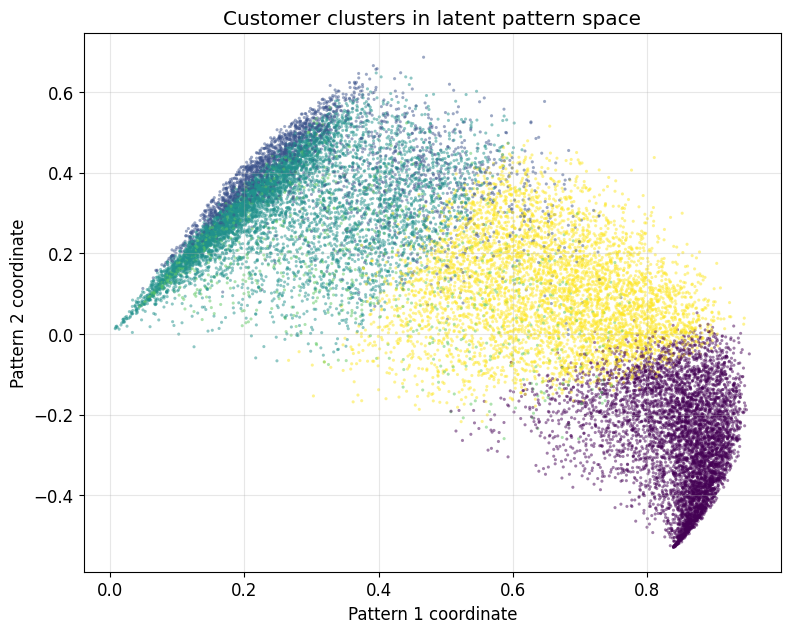

In [ ]:
# ============================================================
# customer clustering in latent space
# ============================================================

from sklearn.cluster import KMeans

# I use the first 10 latent dimensions as customer features.
# These dimensions summarize the main spending behaviour patterns.
customer_features = U[:, :10] * sigma[:10]

# Apply K-Means clustering.
# I choose 5 clusters here as a simple segmentation example.
kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(customer_features)

# Visualize the clusters using the first 2 latent coordinates
plt.figure(figsize=(9, 7))
plt.scatter(
    coords[idx_sample, 0],
    coords[idx_sample, 1],
    c=clusters[idx_sample],
    s=5,
    alpha=0.5,
    linewidths=0
)

plt.xlabel('Pattern 1 coordinate')
plt.ylabel('Pattern 2 coordinate')
plt.title('Customer clusters in latent pattern space')
plt.grid(True, alpha=0.3)
plt.savefig("customer_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

## Clustering explanation

In [ ]:
# ============================================================
#  Describe customer clusters
# ============================================================
# This section helps us understand what each cluster represents.
# We connect each customer back to their cluster and then check
# which product categories are most important in each cluster.

cluster_df = pd.DataFrame({
    "customer_idx": np.arange(len(clusters)),
    "cluster": clusters
})

# Add the cluster label to the aggregated transaction data
agg_with_cluster = agg.merge(cluster_df, on="customer_idx")

# For each cluster and category, calculate the average observed spending.
# Note: this uses observed purchases only, because agg contains non-zero transactions.
cluster_profile = (
    agg_with_cluster
    .groupby(["cluster", "category_idx"])["total_amount"]
    .mean()
    .unstack(fill_value=0)
)

TOP_N = 5

for cluster_id in cluster_profile.index:
    print(f"\n=== Cluster {cluster_id} ===")

    top_categories = (
        cluster_profile.loc[cluster_id]
        .sort_values(ascending=False)
        .head(TOP_N)
    )

    for cat_idx, val in top_categories.items():
        category_name = idx_to_category.get(cat_idx, cat_idx)
        print(f"{category_name} : {val:.2f}")


=== Cluster 0 ===
201000002 : 2369322.52
143040202 : 683801.42
146050006 : 528960.36
123040001 : 513538.46
207011001 : 423161.63

=== Cluster 1 ===
202010902 : 833984.22
104050001 : 527252.22
143040202 : 482988.14
146050002 : 482075.67
101020102 : 409153.74

=== Cluster 2 ===
Ignore : 24055551.77
208020104 : 2530741.19
118010101 : 2419127.27
143040202 : 1147166.79
146050002 : 660241.96

=== Cluster 3 ===
123040001 : 1825891.88
201000002 : 807727.30
127030404 : 569440.90
104050001 : 538955.61
127040406 : 456213.65

=== Cluster 4 ===
201000002 : 877114.39
143040202 : 588139.55
104050001 : 468075.46
123040001 : 431935.51
143030102 : 423019.02


The output shows the top product categories for each customer cluster.  
The number beside each category is the average observed spending in that category for customers in that cluster.  
Higher values mean that the category is more important for describing that cluster.

---
## Step 7 —  Randomized SVD vs Sparse SVD

This section compares randomized SVD with sparse SVD. The timing shows which method is faster for different ranks, and the singular value error shows whether the approximate method gives similar singular values.

In [ ]:
# ============================================================
# Compare randomized SVD and sparse SVD
# ============================================================
# In this section compares two ways of computing the top singular values:
# 1. randomized_svd: an approximate randomized method
# 2. svds: a sparse SVD method from scipy

ks_bench = [10, 50, 100, 200]
ks_bench = [k for k in ks_bench if k < min(A_normalized.shape)]  # safety check

results = []

for k in ks_bench:
    # Randomized SVD timing
    t0 = time.time()
    Ur, sr, Vtr = randomized_svd(
        A_normalized,
        n_components=k,
        random_state=RANDOM_STATE
    )
    t_rand = time.time() - t0

    # Sparse SVD timing
    t0 = time.time()
    Ue, se, Vte = svds(A_normalized, k=k)
    t_sparse = time.time() - t0

    # svds returns singular values in ascending order, so I sort them descending
    se_sorted = np.sort(se)[::-1]

    # Compare singular values from both methods
    sigma_err = np.linalg.norm(sr - se_sorted) / np.linalg.norm(se_sorted)

    results.append({
        "k": k,
        "randomized_svd_time": round(t_rand, 2),
        "sparse_svds_time": round(t_sparse, 2),
        "relative_singular_value_error": f"{sigma_err:.2e}"
    })

    print(
        f"k={k:4d}  "
        f"randomized_svd={t_rand:.2f}s  "
        f"sparse_svds={t_sparse:.2f}s  "
        f"sigma_error={sigma_err:.2e}"
    )

results_df = pd.DataFrame(results)
results_df

k=  10  randomized_svd=3.52s  sparse_svds=2.07s  sigma_error=3.91e-07
k=  50  randomized_svd=7.64s  sparse_svds=7.85s  sigma_error=1.98e-03
k= 100  randomized_svd=14.37s  sparse_svds=13.60s  sigma_error=1.42e-03
k= 200  randomized_svd=28.37s  sparse_svds=23.48s  sigma_error=1.31e-03


,k,randomized_svd_time,sparse_svds_time,relative_singular_value_error
0,10,3.52,2.07,3.91e-07
1,50,7.64,7.85,1.98e-03
2,100,14.37,13.60,1.42e-03
3,200,28.37,23.48,1.31e-03


---
## Example - Customer interpretation

In [ ]:
# ============================================================
# Example customer interpretation
# ============================================================
# This is a simple example showing how we can interpret one customer
# using their original purchases and their SVD latent coordinates.

CLIENT_IDX = 0  # Can replace this with another customer index

# Original spending of this customer across product categories
client_row = A[CLIENT_IDX].toarray().flatten()

# Top purchased categories for this customer
top_category_idx = np.argsort(client_row)[-10:][::-1]

print("Top purchased categories:")
for idx in top_category_idx:
    category_name = str(idx_to_category.get(idx, idx))
    print(f"  Category: {category_name:30s}  spend = {client_row[idx]:.2f}")

# Customer coordinates in the first few latent patterns
print("\nPattern coordinates based on SVD (first 5):")
client_coords = U[CLIENT_IDX, :5] * sigma[:5]

for i, value in enumerate(client_coords):
    print(f"  Pattern {i+1}: {value:.3f}")

# Dominant latent pattern for this customer
dominant = np.argmax(np.abs(client_coords))

print(f"\nDominant pattern: Pattern {dominant + 1}")

print("\nInterpretation:")
print(f"This customer is most strongly associated with Pattern {dominant + 1}.")
print("This suggests that their spending behaviour is mainly explained by the categories linked to that latent pattern.")

Top purchased categories:
  Category: 160040101                       spend = 278884.22
  Category: 158020201                       spend = 159980.00
  Category: 128080302                       spend = 151460.00
  Category: 152010102                       spend = 99980.00
  Category: 201000002                       spend = 94070.40
  Category: 118030005                       spend = 89930.00
  Category: 122000018                       spend = 87490.22
  Category: 160030102                       spend = 71990.00
  Category: 120020008                       spend = 68922.52
  Category: 140060101                       spend = 65890.00

Pattern coordinates based on SVD (first 5):
  Pattern 1: 0.379
  Pattern 2: 0.206
  Pattern 3: -0.048
  Pattern 4: -0.165
  Pattern 5: -0.183

Dominant pattern: Pattern 1

Interpretation:
This customer is most strongly associated with Pattern 1.
This suggests that their spending behaviour is mainly explained by the categories linked to that latent pattern.


## Matrix Completion Validation

In this section, I test the matrix completion idea. hiding 10% of the observed customer-category spending values and train the SVD model using the remaining 90%. Then predict the hidden values and compare them with the true values using RMSE and MAE. Because the full matrix is large, I use a random sample of customers to avoid memory problems in Colab.

In [ ]:
# ============================================================
# Simple matrix completion validation on a sample
# ============================================================

from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.utils.extmath import randomized_svd
from scipy.sparse import csr_matrix

# To avoid using too much RAM in Colab, I use a sample of customers.

N_CUSTOMER_SAMPLE = min(50000, A.shape[0])
np.random.seed(RANDOM_STATE)

sample_customers = np.random.choice(
    A.shape[0],
    size=N_CUSTOMER_SAMPLE,
    replace=False
)

# Create a smaller customer-category matrix
A_sample = A[sample_customers, :]

# Normalize the sampled matrix
A_sample_normalized = normalize(A_sample, norm='l2', axis=1)

print("Sample matrix shape:", A_sample_normalized.shape)
print("Sample non-zero entries:", A_sample_normalized.nnz)

# Convert only the sample matrix to COO format
A_coo = A_sample_normalized.tocoo()

rows = A_coo.row
cols = A_coo.col
vals = A_coo.data

# Hide 10% of the observed entries
all_indices = np.arange(len(vals))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.10,
    random_state=RANDOM_STATE
)

# Build training matrix using only the training observed entries
A_train = csr_matrix(
    (
        vals[train_idx],
        (rows[train_idx], cols[train_idx])
    ),
    shape=A_sample_normalized.shape
)

test_rows = rows[test_idx]
test_cols = cols[test_idx]
test_vals = vals[test_idx]

# Use a moderate rank to keep computation simple
k_completion = min(50, A_train.shape[1] - 1)

U_train, sigma_train, Vt_train = randomized_svd(
    A_train,
    n_components=k_completion,
    random_state=RANDOM_STATE
)

# Predict the hidden entries
pred_vals = np.sum(
    (U_train[test_rows, :] * sigma_train) * Vt_train[:, test_cols].T,
    axis=1
)

# Evaluate prediction quality
svd_rmse = np.sqrt(mean_squared_error(test_vals, pred_vals))
svd_mae = mean_absolute_error(test_vals, pred_vals)

print("SVD matrix completion results on sampled data:")
print(f"Customer sample size: {N_CUSTOMER_SAMPLE}")
print(f"Rank used: {k_completion}")
print(f"Held-out RMSE: {svd_rmse:.6f}")
print(f"Held-out MAE : {svd_mae:.6f}")

Sample matrix shape: (50000, 498)
Sample non-zero entries: 3271744
SVD matrix completion results on sampled data:
Customer sample size: 50000
Rank used: 50
Held-out RMSE: 0.119997
Held-out MAE : 0.057983


In [ ]:
# ============================================================
# Baseline comparison
# ============================================================

# Baseline: predict each hidden entry using the average observed value
# of that product category in the training matrix.

category_sum = np.asarray(A_train.sum(axis=0)).ravel()
category_count = np.asarray((A_train != 0).sum(axis=0)).ravel()

category_mean = np.divide(
    category_sum,
    category_count,
    out=np.zeros_like(category_sum, dtype=float),
    where=category_count != 0
)

baseline_pred = category_mean[test_cols]

baseline_rmse = np.sqrt(mean_squared_error(test_vals, baseline_pred))
baseline_mae = mean_absolute_error(test_vals, baseline_pred)

print("Baseline results:")
print(f"Baseline RMSE: {baseline_rmse:.6f}")
print(f"Baseline MAE : {baseline_mae:.6f}")

print("\nComparison:")
print(f"SVD RMSE improvement over baseline: {baseline_rmse - svd_rmse:.6f}")
print(f"SVD MAE improvement over baseline : {baseline_mae - svd_mae:.6f}")

Baseline results:
Baseline RMSE: 0.085251
Baseline MAE : 0.048754

Comparison:
SVD RMSE improvement over baseline: -0.034746
SVD MAE improvement over baseline : -0.009229


 The errors show how close the predictions are to the true hidden values

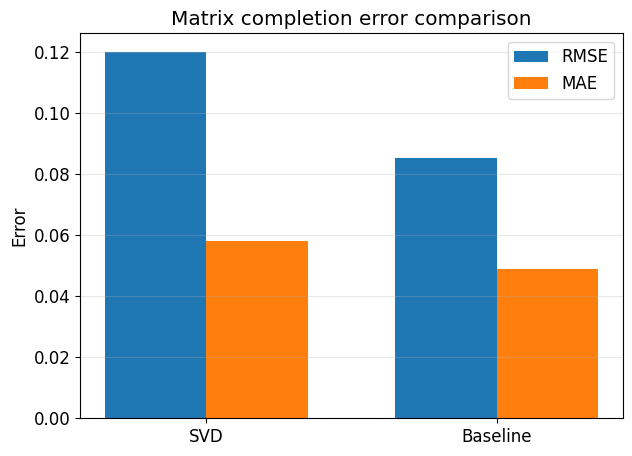

In [ ]:
# ============================================================
# Compare SVD and baseline errors
# ============================================================

methods = ["SVD", "Baseline"]
rmse_values = [svd_rmse, baseline_rmse]
mae_values = [svd_mae, baseline_mae]

plt.figure(figsize=(7, 5))
x = np.arange(len(methods))
width = 0.35

plt.bar(x - width/2, rmse_values, width, label="RMSE")
plt.bar(x + width/2, mae_values, width, label="MAE")

plt.xticks(x, methods)
plt.ylabel("Error")
plt.title("Matrix completion error comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.savefig("matrix_completion_error_comparison.png", dpi=300, bbox_inches="tight")
plt.show()